In [8]:
# ============================================================
# NOTEBOOK 5 — BASELINE XGBOOST
# CELL 1 — IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
print("Libraries imported successfully.")

# ============================================================
# CELL 2 — DEFINE DATA DIRECTORIES
# ============================================================
BASE_DIR = Path.cwd()
#PROCESSED_DIR = BASE_DIR / "data/processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Processed data directory:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)

Libraries imported successfully.
Processed data directory: ..\data\processed
Models directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models
Results directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results


In [9]:
# ============================================================
# CELL 3 — LOAD SMOTENC-BALANCED TRAINING DATA
# ============================================================

X_train_smotenc_path = PROCESSED_DIR / "X_train_smotenc.csv"
y_train_smotenc_path = PROCESSED_DIR / "y_train_smotenc.csv"

# Load SMOTENC-balanced predictors
X_train_smotenc = pd.read_csv(
    X_train_smotenc_path
)

# Load SMOTENC-balanced target
y_train_smotenc = pd.read_csv(
    y_train_smotenc_path
).squeeze()

print("=" * 60)
print("SMOTENC TRAINING DATA LOADED")
print("=" * 60)

print("X_train_smotenc shape:", X_train_smotenc.shape)
print("y_train_smotenc shape:", y_train_smotenc.shape)

print("\nSMOTENC target distribution:")
print(y_train_smotenc.value_counts().sort_index())

print("\nNumber of predictors:", X_train_smotenc.shape[1])

SMOTENC TRAINING DATA LOADED
X_train_smotenc shape: (658, 58)
y_train_smotenc shape: (658,)

SMOTENC target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

Number of predictors: 58


In [10]:
# ============================================================
# CELL 5 — LOAD ORIGINAL UNTOUCHED TEST DATA
# ============================================================

X_test_clean_path = PROCESSED_DIR / "X_test_clean.csv"
y_test_clean_path = PROCESSED_DIR / "y_test_clean.csv"

X_test_clean = pd.read_csv(X_test_clean_path)
y_test_clean = pd.read_csv(y_test_clean_path).squeeze()

print("Original X_test_clean shape:", X_test_clean.shape)
print("Original y_test_clean shape:", y_test_clean.shape)

print("\nOriginal test target distribution:")
print(y_test_clean.value_counts().sort_index())

Original X_test_clean shape: (114, 58)
Original y_test_clean shape: (114,)

Original test target distribution:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64


In [11]:
# ============================================================
# CELL 6 — VERIFY FEATURE ALIGNMENT
# ============================================================

print("Number of training features:", X_train_smotenc.shape[1])
print("Number of test features:", X_test_clean.shape[1])

print("\nFeature names identical:",
    list(X_train_smotenc.columns) == list(X_test_clean.columns))

if list(X_train_smotenc.columns) != list(X_test_clean.columns):
    print("\nWARNING: Feature mismatch detected!")

    print("\nTraining-only columns:")
    print(set(X_train_smotenc.columns) - set(X_test_clean.columns))

    print("\nTest-only columns:")
    print(set(X_test_clean.columns) - set(X_train_smotenc.columns))
else:
    print("✓ Training and test feature columns are aligned.")

Number of training features: 58
Number of test features: 58

Feature names identical: True
✓ Training and test feature columns are aligned.


In [12]:
# ============================================================
# CELL 7 — CHECK DATA TYPES
# ============================================================

print("Training data types:")
print(X_train_smotenc.dtypes)

print("\nTest data types:")
print(X_test_clean.dtypes)

Training data types:
GPA_S1                           float64
CA_AVG                           float64
EXAM_AVG                         float64
CLIN_AVG                         float64
LAB_AVG                          float64
ATT_RATE                         float64
ASSIGN_LATE                        int64
Age_group                          int64
Gender                             int64
Year_study                         int64
SES                                int64
Financial_diff                     int64
Employment_hrs                     int64
Study_hrs_day                      int64
Sleep_hrs                          int64
Self_risk_percep                   int64
Reviews notes within 24h           int64
Understands content pre-exam       int64
Seeks help when stuck              int64
Uses library regularly             int64
Completes readings                 int64
Takes organised notes              int64
Concentration in self-study        int64
Participates in class              i

In [13]:
# ============================================================
# CELL 8 — CHECK MISSING VALUES
# ============================================================

train_missing = X_train_smotenc.isnull().sum()
test_missing = X_test_clean.isnull().sum()

print("Total missing values in training:",
    train_missing.sum())

print("Total missing values in test:",
    test_missing.sum())

if train_missing.sum() > 0:
    print("\nTraining columns with missing values:")
    print(train_missing[train_missing > 0])

if test_missing.sum() > 0:
    print("\nTest columns with missing values:")
    print(test_missing[test_missing > 0])

Total missing values in training: 0
Total missing values in test: 0


In [14]:
# ============================================================
# CELL 9 — BASELINE XGBOOST MODEL
# ============================================================

baseline_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Baseline XGBoost model created successfully.")

Baseline XGBoost model created successfully.


In [15]:
# ============================================================
# CELL 10 — TRAIN BASELINE XGBOOST
# ============================================================

print("Training baseline XGBoost...")

baseline_xgb.fit(
    X_train_smotenc,
    y_train_smotenc
)

print("✓ Baseline XGBoost training completed.")

Training baseline XGBoost...


✓ Baseline XGBoost training completed.


In [16]:
# ============================================================
# CELL 11 — GENERATE TEST PREDICTIONS
# ============================================================

y_pred = baseline_xgb.predict(X_test_clean)

y_prob = baseline_xgb.predict_proba(X_test_clean)[:, 1]

print("Predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(y_pred).value_counts().sort_index())

Predictions generated successfully.

Prediction distribution:
0    90
1    24
Name: count, dtype: int64


In [17]:
# ============================================================
# CELL 12 — EVALUATE BASELINE XGBOOST
# ============================================================

accuracy = accuracy_score(y_test_clean, y_pred)

precision = precision_score(
    y_test_clean,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test_clean,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_clean,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test_clean,
    y_prob
)

print("=" * 60)
print("BASELINE XGBOOST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

BASELINE XGBOOST PERFORMANCE
Accuracy : 0.7105
Precision: 0.4583
Recall   : 0.3548
F1-score : 0.4000
ROC-AUC  : 0.6502


In [18]:
# ============================================================
# CELL 13 — CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_clean,
        y_pred,
        target_names=["Not At-Risk", "At-Risk"],
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not At-Risk       0.78      0.84      0.81        83
     At-Risk       0.46      0.35      0.40        31

    accuracy                           0.71       114
   macro avg       0.62      0.60      0.60       114
weighted avg       0.69      0.71      0.70       114



Confusion Matrix:
[[70 13]
 [20 11]]


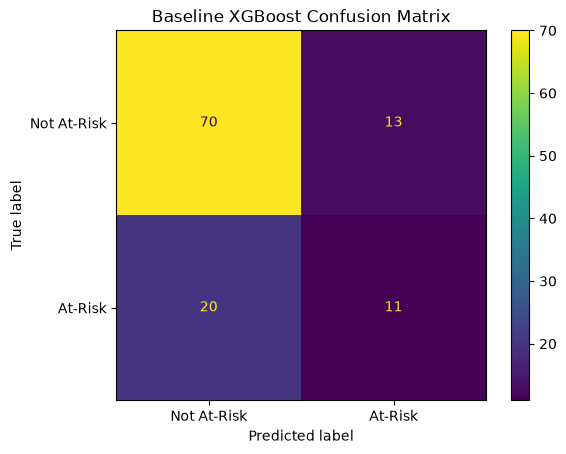

In [19]:
# ============================================================
# CELL 14 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_clean, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not At-Risk", "At-Risk"]
)

disp.plot()
plt.title("Baseline XGBoost Confusion Matrix")
plt.show()

In [20]:
# ============================================================
# CELL 15 — SAVE BASELINE XGBOOST MODEL
# ============================================================

import joblib

baseline_model_path = MODELS_DIR / "baseline_xgboost.pkl"

joblib.dump(
    baseline_xgb,
    baseline_model_path
)

print("Baseline XGBoost model saved successfully.")
print("Saved to:", baseline_model_path)

Baseline XGBoost model saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\baseline_xgboost.pkl


In [21]:
# ============================================================
# CELL 16 — SAVE BASELINE RESULTS
# ============================================================

baseline_results = pd.DataFrame({
    "Model": ["Baseline XGBoost"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "ROC_AUC": [auc]
})

baseline_results_path = RESULTS_DIR / "baseline_xgboost_results.csv"

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline results saved successfully.")
print("Saved to:", baseline_results_path)

display(baseline_results)

Baseline results saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\baseline_xgboost_results.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline XGBoost,0.710526,0.458333,0.354839,0.4,0.650214
